# Curriculum Band Classifier - Tokenizer based method

This notebook provides a complete solution for classifying dataset records into B0-B5 curriculum bands based on BPE tokenizer token ID frequencies.

## Features
- **Automatic Classification**: Classify text into B0-B5 difficulty bands
- **Threshold Calibration**: Automatically determine optimal thresholds for your tokenizer
- **Visualization**: Create charts showing band distribution


In [ ]:
# Install required packages (run this first)
# Uncomment if packages are not installed

# !pip install transformers torch numpy tqdm matplotlib

## Configuration

Set your tokenizer path here:

In [ ]:
# ============================================
# CONFIGURATION - Set your tokenizer path here
# ============================================

TOKENIZER_PATH = (
    r"C:\Balaji\erav4\capstone\tokenizer"  # Update this with your actual tokenizer path
)
# Example: TOKENIZER_PATH = r"C:\Balaji\erav4\capstone\tokenizer"

print(f"Tokenizer path set to: {TOKENIZER_PATH}")

## Imports

In [6]:
import json
import numpy as np
from pathlib import Path
from typing import Dict, List, Any, Tuple
from collections import Counter
from transformers import AutoTokenizer
from tqdm import tqdm
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

print("✓ All imports successful!")

✓ All imports successful!


In [25]:
# Complete CurriculumBandClassifier class
# This includes all functionality: classification, dataset processing, and visualization

MIN_TOKENS = 5
REJECTION_REASON = "Rejected: below minimum sequence length requirement"


class CurriculumBandClassifier:
    """
    Classifies text samples into B0-B5 curriculum bands based on token ID statistics.
    """

    TOKEN_ID_THRESHOLDS = {
        "B0": {
            "avg_max": 5000,
            "max_max": 10000,
            "p95_max": 8000,
            "description": "Nursery: Very high frequency tokens, simple language",
        },
        "B1": {
            "avg_max": 10000,
            "max_max": 20000,
            "p95_max": 15000,
            "description": "Primary: High frequency tokens, everyday language",
        },
        "B2": {
            "avg_max": 20000,
            "max_max": 40000,
            "p95_max": 30000,
            "description": "High School: Medium frequency, structured knowledge",
        },
        "B3": {
            "avg_max": 40000,
            "max_max": 70000,
            "p95_max": 60000,
            "description": "Undergraduate: Lower frequency, technical content",
        },
        "B4": {
            "avg_max": 70000,
            "max_max": 100000,
            "p95_max": 90000,
            "description": "Graduate: Low frequency, complex reasoning",
        },
        "B5": {
            "avg_max": float("inf"),
            "max_max": float("inf"),
            "p95_max": float("inf"),
            "description": "PhD: Very low frequency, advanced/rare terms",
        },
    }

    def __init__(self, local_tokenizer_path: str = None, model_id: str = None):
        if local_tokenizer_path:
            self.tokenizer = AutoTokenizer.from_pretrained(
                local_tokenizer_path, use_fast=True, local_files_only=True
            )
            print(f"✓ Loaded tokenizer from: {local_tokenizer_path}")
        elif model_id:
            self.tokenizer = AutoTokenizer.from_pretrained(model_id)
            print(f"✓ Loaded tokenizer from HuggingFace: {model_id}")
        else:
            raise ValueError("Either local_tokenizer_path or model_id must be provided")

        vocab_size = (
            len(self.tokenizer.get_vocab())
            if hasattr(self.tokenizer, "get_vocab")
            else "unknown"
        )
        print(
            f"✓ Vocabulary size: {vocab_size:,}"
            if isinstance(vocab_size, int)
            else f"✓ Vocabulary size: {vocab_size}"
        )

    def tokenize_text(self, text: str) -> List[int]:
        return self.tokenizer.encode(text, add_special_tokens=False)

    def calculate_token_stats(self, token_ids: List[int]) -> Dict[str, float]:
        if not token_ids:
            return {
                "avg": 0.0,
                "max": 0,
                "min": 0,
                "p50": 0.0,
                "p95": 0.0,
                "p99": 0.0,
                "count": 0,
            }
        token_array = np.array(token_ids)
        return {
            "avg": float(np.mean(token_array)),
            "max": int(np.max(token_array)),
            "min": int(np.min(token_array)),
            "p50": float(np.percentile(token_array, 50)),
            "p95": float(np.percentile(token_array, 95)),
            "p99": float(np.percentile(token_array, 99)),
            "count": len(token_ids),
        }

    def classify_band(
        self, token_stats: Dict[str, float]
    ) -> Tuple[str, Dict[str, Any]]:
        avg_id, max_id, p95_id = (
            token_stats["avg"],
            token_stats["max"],
            token_stats["p95"],
        )
        for band in ["B0", "B1", "B2", "B3", "B4", "B5"]:
            th = self.TOKEN_ID_THRESHOLDS[band]
            if (
                avg_id <= th["avg_max"]
                and max_id <= th["max_max"]
                and p95_id <= th["p95_max"]
            ):
                return band, {
                    "band": band,
                    "description": th["description"],
                    "avg_token_id": avg_id,
                    "max_token_id": max_id,
                    "p95_token_id": p95_id,
                    "reason": f"avg={avg_id:.1f} <= {th['avg_max']}, max={max_id} <= {th['max_max']}, p95={p95_id:.1f} <= {th['p95_max']}",
                }
        return "B5", {
            "band": "B5",
            "description": "PhD: Very low frequency",
            "avg_token_id": avg_id,
            "max_token_id": max_id,
            "p95_token_id": p95_id,
            "reason": "Exceeded all thresholds",
        }

    def process_record(
        self, record: Dict[str, Any], text_field: str = "text"
    ) -> Dict[str, Any]:
        if text_field not in record:
            raise ValueError(
                f"Field '{text_field}' not found. Available: {list(record.keys())}"
            )
        text = record[text_field]
        if isinstance(text, list):
            text = " ".join(text)
        elif not isinstance(text, str):
            text = str(text)
        token_ids = self.tokenize_text(text)
        token_stats = self.calculate_token_stats(token_ids)
        band, metadata = self.classify_band(token_stats)
        result = record.copy()
        result["curriculum_band"] = band
        result["token_stats"] = token_stats
        result["classification_metadata"] = metadata
        return result

    def process_dataset(
        self,
        input_file: str,
        output_file: str,
        text_field: str = "text",
        input_format: str = "jsonl",
        rejected_output_file: str = "rejected_below_min_tokens.jsonl",
    ) -> Dict[str, int]:
        print(f"\nProcessing: {input_file}")
        records = []

        if input_format == "jsonl":
            with open(input_file, "r", encoding="utf-8") as f:
                for line in f:
                    if line.strip():
                        records.append(json.loads(line))
        else:
            with open(input_file, "r", encoding="utf-8") as f:
                data = json.load(f)
                records = data if isinstance(data, list) else [data]

        print(f"Found {len(records)} records\n")

        classified_records = []
        rejected_records = []

        band_counts = {"B0": 0, "B1": 0, "B2": 0, "B3": 0, "B4": 0, "B5": 0}

        for record in tqdm(records, desc="Classifying"):
            try:
                text = record.get(text_field, "")
                token_ids = self.tokenizer.encode(text, add_special_tokens=False)
                token_count = len(token_ids)
                print(token_count)

                # 🔹 Minimum token length check
                if token_count < MIN_TOKENS:
                    record["token_count"] = token_count
                    record["rejection_reason"] = REJECTION_REASON
                    rejected_records.append(record)
                    continue

                classified = self.process_record(record, text_field)
                classified["token_count"] = token_count
                classified_records.append(classified)
                band_counts[classified["curriculum_band"]] += 1

            except Exception as e:
                print(f"Error: {e}")
                continue

        # Save classified records
        output_path = Path(output_file)
        output_path.parent.mkdir(parents=True, exist_ok=True)

        if output_file.endswith(".jsonl"):
            with open(output_file, "w", encoding="utf-8") as f:
                for r in classified_records:
                    f.write(json.dumps(r, ensure_ascii=False) + "\n")
        else:
            with open(output_file, "w", encoding="utf-8") as f:
                json.dump(classified_records, f, ensure_ascii=False, indent=2)

        # Save rejected records separately
        if rejected_records:
            with open(rejected_output_file, "w", encoding="utf-8") as f:
                for r in rejected_records:
                    f.write(json.dumps(r, ensure_ascii=False) + "\n")

        # Summary
        print("\n" + "=" * 60)
        print("CLASSIFICATION SUMMARY")
        print("=" * 60)

        total = len(classified_records)
        rejected_total = len(rejected_records)

        for band in ["B0", "B1", "B2", "B3", "B4", "B5"]:
            count = band_counts[band]
            pct = (count / total * 100) if total > 0 else 0
            print(
                f"{band:3s}: {count:6d} ({pct:5.1f}%) - {self.TOKEN_ID_THRESHOLDS[band]['description']}"
            )

        print("-" * 60)
        print(f"Accepted records : {total}")
        print(f"Rejected records : {rejected_total} (below minimum sequence length)")
        print("=" * 60)

        return band_counts

    def visualize_band_distribution(
        self,
        classified_file: str,
        output_file: str = None,
        input_format: str = "jsonl",
        title: str = None,
    ):
        records = []
        if input_format == "jsonl":
            with open(classified_file, "r", encoding="utf-8") as f:
                for line in f:
                    if line.strip():
                        records.append(json.loads(line))
        else:
            with open(classified_file, "r", encoding="utf-8") as f:
                data = json.load(f)
                records = data if isinstance(data, list) else [data]
        band_counts = Counter()
        for r in records:
            if "curriculum_band" in r:
                band_counts[r["curriculum_band"]] += 1
        for band in ["B0", "B1", "B2", "B3", "B4", "B5"]:
            if band not in band_counts:
                band_counts[band] = 0
        colors = {
            "B0": "#d4edda",
            "B1": "#c3e6cb",
            "B2": "#fff4e1",
            "B3": "#ffe4b5",
            "B4": "#f8d7da",
            "B5": "#f5c6cb",
        }
        band_names = {
            "B0": "B0: Nursery",
            "B1": "B1: Primary",
            "B2": "B2: High School",
            "B3": "B3: Undergraduate",
            "B4": "B4: Graduate",
            "B5": "B5: PhD",
        }
        bands = ["B0", "B1", "B2", "B3", "B4", "B5"]
        counts = [band_counts[b] for b in bands]
        total = sum(counts)
        percentages = [(c / total * 100) if total > 0 else 0 for c in counts]
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
        if title is None:
            title = f"Curriculum Band Distribution\n({total:,} total records)"
        fig.suptitle(title, fontsize=16, fontweight="bold", y=1.02)
        bars = ax1.bar(
            bands,
            counts,
            color=[colors[b] for b in bands],
            edgecolor="black",
            linewidth=1.5,
        )
        ax1.set_xlabel("Curriculum Band", fontsize=12, fontweight="bold")
        ax1.set_ylabel("Number of Records", fontsize=12, fontweight="bold")
        ax1.set_title("Band Distribution (Count)", fontsize=14, fontweight="bold")
        ax1.grid(axis="y", alpha=0.3, linestyle="--")
        for bar, count, pct in zip(bars, counts, percentages):
            if bar.get_height() > 0:
                ax1.text(
                    bar.get_x() + bar.get_width() / 2.0,
                    bar.get_height(),
                    f"{count:,}\n({pct:.1f}%)",
                    ha="center",
                    va="bottom",
                    fontsize=10,
                    fontweight="bold",
                )
        non_zero = [(i, counts[i]) for i in range(len(bands)) if counts[i] > 0]
        if non_zero:
            indices, pie_counts = zip(*non_zero)
            pie_bands = [bands[i] for i in indices]
            pie_colors = [colors[b] for b in pie_bands]
            pie_labels = [
                f"{band_names[b]}\n{c:,} ({c / total * 100:.1f}%)"
                for b, c in zip(pie_bands, pie_counts)
            ]
            ax2.pie(
                pie_counts,
                labels=pie_labels,
                colors=pie_colors,
                autopct="",
                startangle=90,
                textprops={"fontsize": 10, "fontweight": "bold"},
            )
        ax2.set_title("Band Distribution (Percentage)", fontsize=14, fontweight="bold")
        plt.tight_layout()
        if output_file:
            plt.savefig(output_file, dpi=300, bbox_inches="tight")
            print(f"\n✓ Visualization saved to: {output_file}")
        else:
            plt.show()
        return None


print("✓ CurriculumBandClassifier class loaded!")

✓ CurriculumBandClassifier class loaded!


## 5. Initialize Classifier with Local Tokenizer

In [26]:
# Initialize classifier with local tokenizer
classifier = CurriculumBandClassifier(local_tokenizer_path=TOKENIZER_PATH)
print("\n✓ Classifier ready!")

✓ Loaded tokenizer from: C:\Balaji\erav4\capstone\tokenizer
✓ Vocabulary size: 128,256

✓ Classifier ready!


In [27]:
# Sample texts for each band
SAMPLE_TEXTS = {
    "B0": [
        "The cat sat on the mat. It was happy.",
        "Hello world! How are you today?",
        "I like to play outside. The sun is bright.",
    ],
    "B1": [
        "The weather is nice today. We went to the park and had a picnic.",
        "My favorite subject in school is science. I enjoy learning about animals.",
    ],
    "B2": [
        "Photosynthesis is the process by which plants convert sunlight into energy.",
        "The water cycle describes how water moves through the environment.",
    ],
    "B3": [
        "The quicksort algorithm uses divide-and-conquer with O(n log n) average complexity.",
        "Python's list comprehension provides a concise way to create lists.",
    ],
    "B4": [
        "The transformer architecture employs self-attention mechanisms to model long-range dependencies.",
        "Machine learning models use gradient descent to optimize their parameters.",
    ],
    "B5": [
        "The antidisestablishmentarian framework utilizes zephyr-based optimization for quantum computing applications.",
        "Sophisticated neural architectures leverage attention mechanisms for cross-modal understanding.",
    ],
}


def calibrate_thresholds(classifier, sample_texts=None):
    """Calibrate thresholds by analyzing sample texts from each band."""
    if sample_texts is None:
        sample_texts = SAMPLE_TEXTS

    print("=" * 60)
    print("CALIBRATING THRESHOLDS")
    print("=" * 60)

    band_stats = {}

    for band, texts in sample_texts.items():
        print(f"\n{band} Samples:")
        print("-" * 60)

        all_avgs, all_maxs, all_p95s = [], [], []

        for i, text in enumerate(texts, 1):
            token_ids = classifier.tokenize_text(text)
            stats = classifier.calculate_token_stats(token_ids)
            all_avgs.append(stats["avg"])
            all_maxs.append(stats["max"])
            all_p95s.append(stats["p95"])
            print(f"  Sample {i}: {text[:50]}...")
            print(
                f"    Avg: {stats['avg']:.1f}, Max: {stats['max']}, P95: {stats['p95']:.1f}"
            )

        band_stats[band] = {
            "avg_mean": np.mean(all_avgs),
            "avg_max": np.max(all_avgs),
            "max_mean": np.mean(all_maxs),
            "max_max": np.max(all_maxs),
            "p95_mean": np.mean(all_p95s),
            "p95_max": np.max(all_p95s),
        }
        print(
            f"\n  {band} Summary: Avg mean={band_stats[band]['avg_mean']:.1f}, max={band_stats[band]['avg_max']:.1f}"
        )
        print(
            f"    Max mean={band_stats[band]['max_mean']:.1f}, max={band_stats[band]['max_max']}"
        )
        print(
            f"    P95 mean={band_stats[band]['p95_mean']:.1f}, max={band_stats[band]['p95_max']:.1f}"
        )

    print("\n" + "=" * 60)
    print("SUGGESTED THRESHOLDS")
    print("=" * 60)
    print("\nTOKEN_ID_THRESHOLDS = {")

    bands = ["B0", "B1", "B2", "B3", "B4", "B5"]
    for i, band in enumerate(bands):
        if band in band_stats:
            stats = band_stats[band]
            if i < len(bands) - 1:
                avg_thresh = int(stats["avg_max"] * 1.2)
                max_thresh = int(stats["max_max"] * 1.2)
                p95_thresh = int(stats["p95_max"] * 1.2)
            else:
                avg_thresh = "float('inf')"
                max_thresh = "float('inf')"
                p95_thresh = "float('inf')"
            print(f"    '{band}': {{")
            print(f"        'avg_max': {avg_thresh},")
            print(f"        'max_max': {max_thresh},")
            print(f"        'p95_max': {p95_thresh},")
            print(
                f"        'description': '{classifier.TOKEN_ID_THRESHOLDS[band]['description']}'"
            )
            print("    },")
    print("}")
    print("\n" + "=" * 60)
    print("RECOMMENDATION")
    print("=" * 60)
    print("1. Review suggested thresholds above")
    print("2. Update TOKEN_ID_THRESHOLDS in classifier class if needed")
    print("3. Test with your actual dataset")


# Run calibration
calibrate_thresholds(classifier)

CALIBRATING THRESHOLDS

B0 Samples:
------------------------------------------------------------
  Sample 1: The cat sat on the mat. It was happy....
    Avg: 2847.4, Max: 8415, P95: 8073.0
  Sample 2: Hello world! How are you today?...
    Avg: 2370.1, Max: 9906, P95: 7640.1
  Sample 3: I like to play outside. The sun is bright....
    Avg: 2381.5, Max: 10107, P95: 8633.5

  B0 Summary: Avg mean=2533.0, max=2847.4
    Max mean=9476.0, max=10107
    P95 mean=8115.5, max=8633.5

B1 Samples:
------------------------------------------------------------
  Sample 1: The weather is nice today. We went to the park and...
    Avg: 5608.9, Max: 55562, P95: 20852.0
  Sample 2: My favorite subject in school is science. I enjoy ...
    Avg: 3654.2, Max: 10099, P95: 8863.3

  B1 Summary: Avg mean=4631.5, max=5608.9
    Max mean=32830.5, max=55562
    P95 mean=14857.7, max=20852.0

B2 Samples:
------------------------------------------------------------
  Sample 1: Photosynthesis is the process by w

In [28]:
# Configuration for dataset processing
INPUT_FILE = (
    r"C:\Balaji\erav4\capstone\sample_dataset.jsonl"  # Update with your input file path
)
OUTPUT_FILE = "classified_dataset.jsonl"  # Output file path
TEXT_FIELD = "text"  # Name of field containing text in your dataset
INPUT_FORMAT = "jsonl"  # 'json' or 'jsonl'

# Process dataset
band_counts = classifier.process_dataset(
    input_file=INPUT_FILE,
    output_file=OUTPUT_FILE,
    text_field=TEXT_FIELD,
    input_format=INPUT_FORMAT,
)

Classifying:   0%|                                                                              | 0/10 [00:00<?, ?it/s]


Processing: C:\Balaji\erav4\capstone\sample_dataset.jsonl
Found 10 records

11
15
19


Classifying: 100%|████████████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 234.32it/s]

20
24
27
23
23
26
32

CLASSIFICATION SUMMARY
B0 :      1 ( 10.0%) - Nursery: Very high frequency tokens, simple language
B1 :      1 ( 10.0%) - Primary: High frequency tokens, everyday language
B2 :      1 ( 10.0%) - High School: Medium frequency, structured knowledge
B3 :      4 ( 40.0%) - Undergraduate: Lower frequency, technical content
B4 :      3 ( 30.0%) - Graduate: Low frequency, complex reasoning
B5 :      0 (  0.0%) - PhD: Very low frequency, advanced/rare terms
------------------------------------------------------------
Accepted records : 10
Rejected records : 0 (below minimum sequence length)


## 8. Visualization - Band Distribution

Visualize the distribution of records across B0-B5 bands from your classified dataset.


✓ Visualization saved to: band_distribution.png


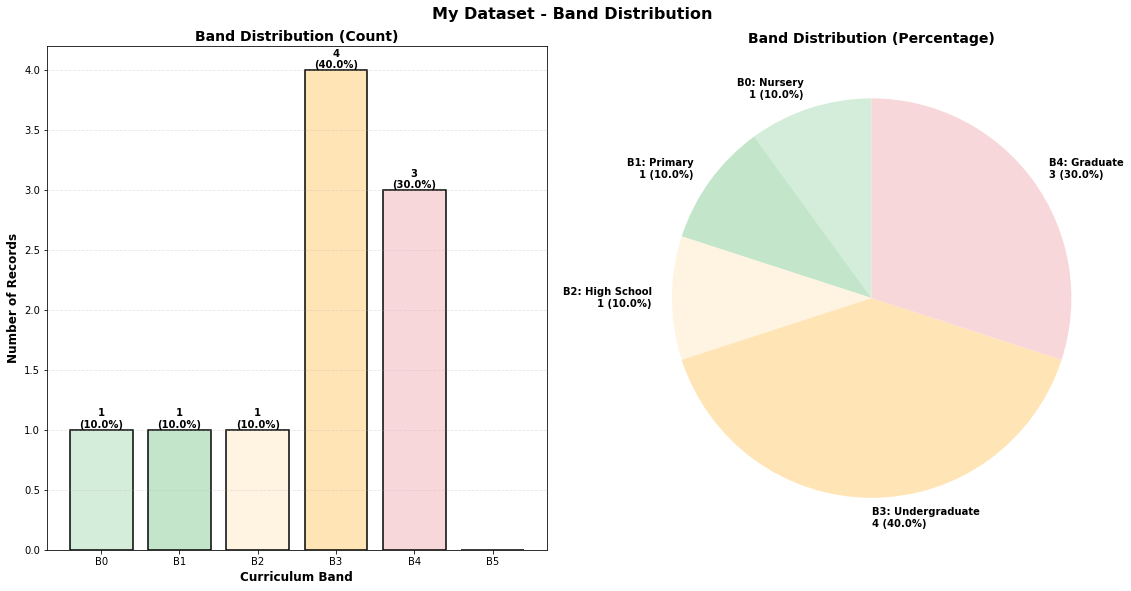

In [29]:
# Configuration for visualization
CLASSIFIED_FILE = (
    "classified_dataset.jsonl"  # Path to classified dataset (output from previous step)
)
OUTPUT_IMAGE = "band_distribution.png"  # Set to None to display interactively
VISUALIZATION_TITLE = "My Dataset - Band Distribution"  # Optional custom title

# Create visualization
classifier.visualize_band_distribution(
    classified_file=CLASSIFIED_FILE,
    output_file=OUTPUT_IMAGE,
    input_format="jsonl",
    title=VISUALIZATION_TITLE,
)